In [2]:
from qutip import *
import numpy as np
import CDHPy.CDHPy_utils as cdh

## Rabi model ##

In [3]:
delta = 1
epsilon = 0
Om = 2*delta
lam_range = np.linspace(0.01,5,100)
beta = 1

In [4]:
def ata(m):
    return 0.5 * np.diag(np.arange(0, 2 * m, 2))

def atpa(m):
    vals = np.sqrt(np.arange(1, m))
    return np.diag(vals, 1) + np.diag(vals, -1)

def H_RC_M(M):
    def H_RC(lam):
        if M == 1:
            H = delta*sigmaz() + epsilon*sigmax()
        else:
            H = ( delta*tensor(qeye(M),sigmaz()) + epsilon*tensor(qeye(M),sigmax()) 
                + lam*tensor(create(M)+destroy(M),sigmax())
                + Om * tensor(Qobj(create(M).full() @ destroy(M).full()),qeye(2)) )
                #+ Om * tensor(create(M)*destroy(M),qeye(2)) )
        return H
    return H_RC

def H_EFF_M(N): 
    def H_EFF(lam):
        M = 100

        H = ( delta * tensor(qeye(M), sigmaz()) 
            + epsilon * tensor(qeye(M), sigmax()) 
            + lam * tensor(create(M) + destroy(M), sigmax()) 
            + Om * tensor(Qobj(create(M).full() @ destroy(M).full()), qeye(2)) )
        
        UP = (lam / Om * tensor(create(M) - destroy(M), sigmax())).expm()
        H_transformed = UP * H * UP.dag()

        # Convert to dense matrix and slice top-left 2N x 2N block
        H_matrix = H_transformed.full()
        block = H_matrix[:2*N, :2*N]

        if N == 1:
            return Qobj(block, dims=[[2], [2]])
        else:
            return Qobj(block, dims=[[2, N], [2, N]])
        
    return H_EFF

def Gamma_func(omega, Gamma, T, shape):

    def nB(omega, T):
        if T == 0.0 or omega == 0.0:
            return 0.0
        return 1.0 / (np.exp(omega / T) - 1.0)
    
    def J_RC(Gamma, omega):
        return Gamma * omega * np.exp(-np.abs(omega) / 1000)

    J = J_RC(Gamma, abs(omega))
    if omega > 0:
        return np.pi * J * (1 + nB(omega, T)) * np.ones(shape)
    if omega < 0:
        return np.pi * J * nB(-omega, T) * np.ones(shape)
    if omega == 0:
        return np.pi * Gamma * T * np.ones(shape)

In [5]:
N = 5
Gamma = 0.01
T = 1.0
lam_range = np.linspace(0.01,5.0,100)

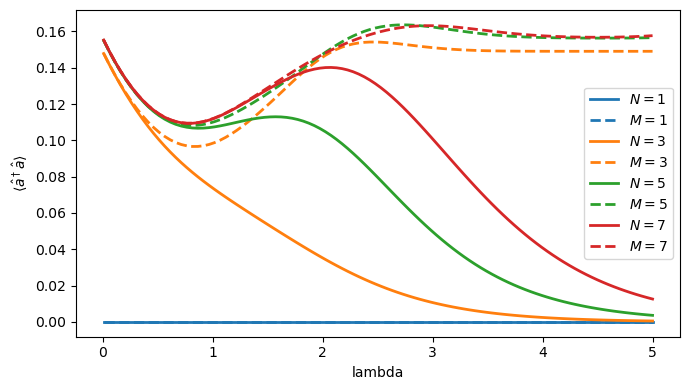

In [ ]:
# couple rabi model to a bath via cavity displacement
import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
cmap = plt.get_cmap("tab10")

for iN,N in enumerate([1,3,5,7]):

    results = np.empty([2,3,100])
    rhos = []
    
    for ilam,lam in enumerate(lam_range):

        # bare Redfield tensor
        H_bare = H_RC_M(N)(lam).full()
        S_bare = [np.kron(atpa(N),np.eye(2))]
        R_bare, U = cdh.build_redfield_tensor(
                    H = H_bare,
                    S_list = S_bare,
                    gamma_func = lambda w: Gamma_func(w, Gamma, T, len(S_bare))
        )

        # CDH Redfield tensor
        H_cdh, S_cdh, UP = cdh.Effective_mapping(
                            delta*sigmaz().full(),
                            [sigmax().full()],
                            [Om],
                            [lam],
                            20,
                            N
        )

        R_cdh, U_cdh = cdh.build_redfield_tensor(
                        H = H_cdh,
                        S_list = S_cdh,
                        gamma_func = lambda w: Gamma_func(w, Gamma, T, len(S_bare))
        )

        for iR,R in enumerate([R_bare,R_cdh]):

            w, v = np.linalg.eig(R)
            idx = np.argmin(np.abs(w))
            rho_ss_vec = v[:, idx]
            d2 = R.shape[0]
            d = int(np.sqrt(d2))

            rho_ss = rho_ss_vec.reshape((d, d), order='F')
            tr = np.trace(rho_ss)
            if np.abs(tr) < 1e-14:
                raise RuntimeError('cannot normalize')
            rho_ss = rho_ss / tr
            rho_ss = 0.5 * (rho_ss + rho_ss.conj().T)
            rhos.append(rho_ss)

            Sx_mat = tensor(qeye(N), sigmax()).full()
            Sz_mat = tensor(qeye(N), sigmaz()).full()
            ata_mat = np.kron(ata(N),qeye(2).full())

            #if iR == 0:
            UP = np.eye(d)

            exp_Sx = np.real(np.trace(rho_ss @ UP @ Sx_mat @ UP.conj().T ))
            exp_Sz = np.real(np.trace(rho_ss @ UP @ Sz_mat @ UP.conj().T ))
            exp_ata = np.real(np.trace(rho_ss @ UP @ ata_mat @ UP.conj().T ))

            results[iR,:,ilam] = exp_Sx, exp_Sz, exp_ata

    plt.plot(lam_range, results[0, 2, :], label=rf'$N={N}$', lw=2, linestyle='solid', color=cmap(iN))
    plt.plot(lam_range, results[1, 2, :], label=rf'$M={N}$', lw=2, linestyle='dashed', color=cmap(iN))

# rhos = np.array(rhos).reshape([d,d,100])
# for i in range(d):
#     plt.plot(lam_range, rhos[i,i,:])
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\langle \hat{a}^\dagger \hat{a} \rangle^{\mathrm{eq}}$')
plt.legend()
plt.tight_layout()
plt.show()

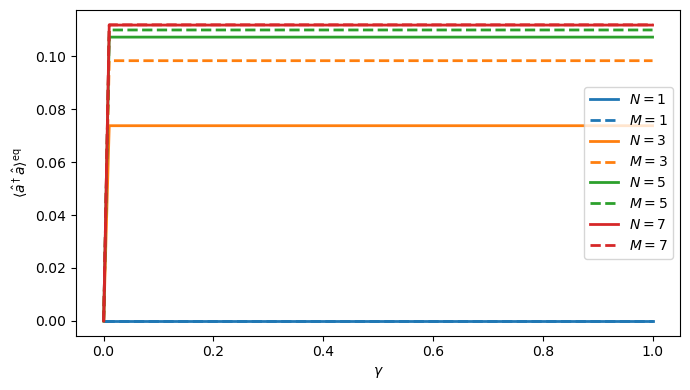

In [ ]:
# couple rabi model to a bath via cavity displacement
import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
cmap = plt.get_cmap("tab10")

lam = 1.0
gam_range = np.linspace(0.01,1.0,100)

for iN,N in enumerate([1,3,5,7]):

    results = np.empty([2,3,len(gam_range)])
    rhos = []
    
    for igam,Gamma in enumerate(gam_range):

        # bare Redfield tensor
        H_bare = H_RC_M(N)(lam).full()
        S_bare = [np.kron(atpa(N),np.eye(2))]
        R_bare, U = cdh.build_redfield_tensor(
                    H = H_bare,
                    S_list = S_bare,
                    gamma_func = lambda w: Gamma_func(w, Gamma, T, len(S_bare))
        )

        # CDH Redfield tensor
        H_cdh, S_cdh, UP = cdh.Effective_mapping(
                            delta*sigmaz().full(),
                            [sigmax().full()],
                            [Om],
                            [lam],
                            20,
                            N
        )

        R_cdh, U_cdh = cdh.build_redfield_tensor(
                        H = H_cdh,
                        S_list = S_cdh,
                        gamma_func = lambda w: Gamma_func(w, Gamma, T, len(S_cdh))
        )

        for iR,R in enumerate([R_bare,R_cdh]):

            w, v = np.linalg.eig(R)
            idx = np.argmin(np.abs(w))
            rho_ss_vec = v[:, idx]
            d2 = R.shape[0]
            d = int(np.sqrt(d2))

            rho_ss = rho_ss_vec.reshape((d, d), order='F')
            tr = np.trace(rho_ss)
            if np.abs(tr) < 1e-14:
                raise RuntimeError('cannot normalize')
            rho_ss = rho_ss / tr
            rho_ss = 0.5 * (rho_ss + rho_ss.conj().T)
            rhos.append(rho_ss)

            Sx_mat = tensor(qeye(N), sigmax()).full()
            Sz_mat = tensor(qeye(N), sigmaz()).full()
            ata_mat = np.kron(ata(N),qeye(2).full())

            #if iR == 0:
            UP = np.eye(d)

            exp_Sx = np.real(np.trace(rho_ss @ UP @ Sx_mat @ UP.conj().T ))
            exp_Sz = np.real(np.trace(rho_ss @ UP @ Sz_mat @ UP.conj().T ))
            exp_ata = np.real(np.trace(rho_ss @ UP @ ata_mat @ UP.conj().T ))

            results[iR,:,igam] = exp_Sx, exp_Sz, exp_ata

    plt.plot(gam_range, results[0, 2, :], label=rf'$N={N}$', lw=2, linestyle='solid', color=cmap(iN))
    plt.plot(gam_range, results[1, 2, :], label=rf'$M={N}$', lw=2, linestyle='dashed', color=cmap(iN))

plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\langle \hat{a}^\dagger \hat{a} \rangle^{\mathrm{eq}}$')
plt.legend()
plt.tight_layout()
plt.show()

## Dicke-Heisenberg model ##

In [ ]:
from get_Hamiltonians import *

# couple rabi model to a bath via cavity displacement
import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
cmap = plt.get_cmap("tab10")

Delta = 1.0
Omega = 2.0 * Delta
gamma_x = gamma_y = gamma_z = 0.33
L = 4

for iN,N in enumerate([1,3]):

    results = np.zeros([2,100])
    rhos = []
    
    for ilam,lam in enumerate(lam_range):

        # bare Redfield tensor
        H_bare = ( H_DH_MN(N,L)(Delta,Omega,lam,gamma_x,gamma_y,gamma_z) ).full()
        S_bare = [np.kron(atpa(N),np.eye(2**L))]
        R_bare, U = cdh.build_redfield_tensor(
                    H = H_bare,
                    S_list = S_bare,
                    gamma_func = lambda w: Gamma_func(w, Gamma, T, len(S_bare))
        )

        # CDH Redfield tensor
        # H_cdh, S_cdh, UP = cdh.Effective_mapping(
        #                     delta*sigmaz().full(),
        #                     [sigmax().full()],
        #                     [Om],
        #                     [lam],
        #                     20,
        #                     N
        # )

        # R_cdh, U_cdh = cdh.build_redfield_tensor(
        #                 H = H_cdh,
        #                 S_list = S_cdh,
        #                 gamma_func = lambda w: Gamma_func(w, Gamma, T, len(S_bare))
        # )

        for iR,R in enumerate([R_bare]):

            w, v = np.linalg.eig(R)
            idx = np.argmin(np.abs(w))
            rho_ss_vec = v[:, idx]
            d2 = R.shape[0]
            d = int(np.sqrt(d2))

            rho_ss = rho_ss_vec.reshape((d, d), order='F')
            tr = np.trace(rho_ss)
            if np.abs(tr) < 1e-14:
                raise RuntimeError('cannot normalize')
            rho_ss = rho_ss / tr
            rho_ss = 0.5 * (rho_ss + rho_ss.conj().T)
            rhos.append(rho_ss)

            UP = np.eye(d)

            ata_mat = np.kron(ata(N),np.eye(2**L))
            exp_ata = np.real(np.trace(rho_ss @ UP @ ata_mat @ UP.conj().T ))

            results[iR,ilam] = exp_ata

    plt.plot(lam_range, results[0, :], label=rf'$N={N}$', lw=2, linestyle='solid', color=cmap(iN))
    plt.plot(lam_range, results[1, :], label=rf'$M={N}$', lw=2, linestyle='dashed', color=cmap(iN))

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\langle \hat{a}^\dagger \hat{a} \rangle^{\mathrm{eq}}$')
plt.legend()
plt.tight_layout()
plt.show()